In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import glob
import numpy as np

In [32]:
files = glob.glob(r'C:\Users\marqjace\seaglider\sg686\TH_Line_11Nov25\p686*.nc')

# fet_pumptime_a = []
fet_pumptime = []
dive = []
scicon_mamps = []

for file in files:
    ds = xr.open_dataset(file)
    # ds = ds.where(ds['trajectory'] >= 60, drop=True)
    if ds['trajectory'].size == 0:
        continue

    # Compute pH pump time (scalar)
    if 'fet_pumptime_a' in ds.variables:
        fet_pump = (ds['fet_pumptime_a'].values + 
                    ds['fet_pumptime_b'].values) / 100
    elif 'fet_pumptime_b' in ds.variables:
        fet_pump = ds['fet_pumptime_b'].values / 100
    else:
        fet_pump = np.nan

    # ensure scalar
    if isinstance(fet_pump, np.ndarray):
        fet_pump = fet_pump.item()
    fet_pumptime.append(float(fet_pump))

    # Dive number scalar
    dive_num = int(ds['trajectory'].values.item())
    dive.append(dive_num)

    # Scicon current scalar extraction
    sensor_mamps = ds['log_SENSOR_MAMPS'].values.item().decode('utf-8')
    str_values_mamps = sensor_mamps.split(',')
    sensor_values = [v if v.lower() != 'nil' else np.nan for v in str_values_mamps]
    scicon_mamps.append(float(sensor_values[6]))


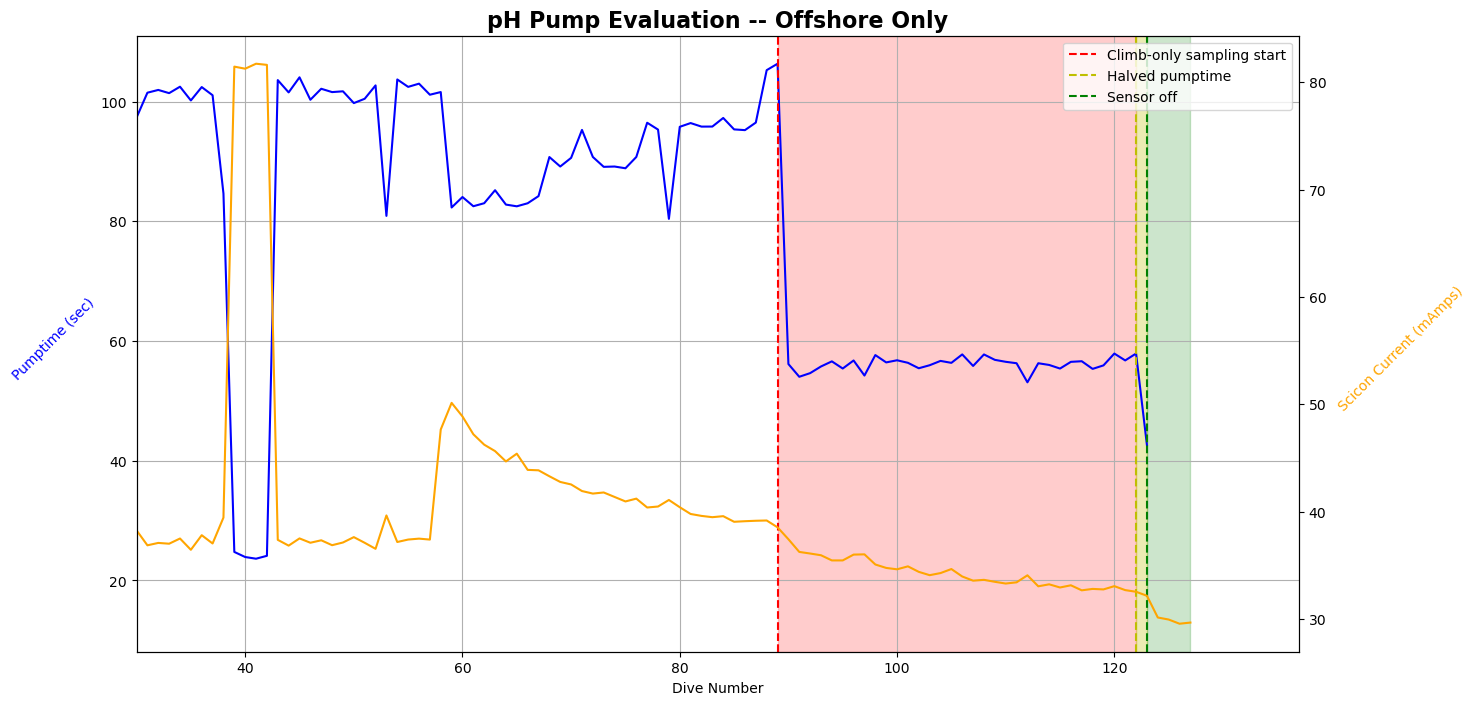

In [39]:
fig, ax = plt.subplots(figsize=(15,8))

pump_plot = ax.plot(dive, fet_pumptime, c='blue')
ax2 = ax.twinx()
mamps_plot = ax2.plot(dive, scicon_mamps, c='orange', label='Scicon Current (mAmps)')

ax.axvline(89, c='r', label='Climb-only sampling start', linestyle='--')
ax.axvspan(89, 122, color='r', alpha=0.2)
ax.axvline(122, c='y', label='Halved pumptime', linestyle='--')
ax.axvspan(122, 123, color='y', alpha=0.3)
ax.axvline(123, c='g', label='Sensor off', linestyle='--')
ax.axvspan(123, np.nanmax(dive), color='g', alpha=0.2)

ax.set_xlim(30, np.nanmax(dive)+10)
ax.set_ylabel('Pumptime (sec)', rotation=45, labelpad=30, color='blue')
ax.set_xlabel('Dive Number')
ax.set_title('pH Pump Evaluation -- Offshore Only', fontweight='bold', fontsize=16)
ax.grid()

# ax.text(np.nanmax(dive)+0.5, fet_pumptime[-1], f'{fet_pumptime[-1]:.1f} sec', color='blue', fontsize=10, va='center')
# ax2.text(np.nanmax(dive)+0.5, scicon_mamps[-1], f'{scicon_mamps[-1]:.1f} mAmps', color='orange', fontsize=10, va='center')

ax2.set_ylabel('Scicon Current (mAmps)', rotation=45, labelpad=50, color='orange')
ax.legend(loc='upper right')